# Editing a sequence graph

`SequenceGraph` has three editing methods:

| Method | Target | Result |
|--------|--------|--------|
| `insert(target, sequence)` | a zero-length position | adds `sequence` there |
| `replace(target, sequence)` | a stretch of bases | swaps those bases for `sequence` |
| `delete(target)` | a stretch of bases | removes those bases |

A target can be a region string such as `"pUC19:100-110"`, a `Locus` returned by `search()`,
an `Annotation`, or a `Position` taken from `locus.start()` or `locus.end()`.

`insert()` and `replace()` return the graph-space `Locus` of the change. Pass that locus to
`add_annotation()` to persist a named annotation in the database.

Every call is recorded as its own operation in the repository history. If an edit is refused,
nothing changes and nothing is recorded.

This notebook works through a few edits to the pUC19 cloning vector:

1. Clone a FLAG tag into the EcoRI site of the multiple cloning site.
2. Change the start codon of *bla* (β-lactamase) from ATG to GTG.
3. Remove the CAP binding site upstream of *lacZα*.
4. Keep two alternative restriction sites side by side with `stack=True`.
5. Annotate the FLAG tag insertion in the database.

## Setup

In [1]:
import pathlib
import tempfile

import gen

EXAMPLES_DIR = pathlib.Path(__file__).parent if "__file__" in dir() else pathlib.Path(".").resolve()

WORK_DIR = pathlib.Path(tempfile.mkdtemp(prefix="gen-editing-"))
repo = gen.Repository(str(WORK_DIR))
reference = repo.import_genbank(str(EXAMPLES_DIR / "puc19.gbk"), sample="reference")
sg_reference = reference[0]

`export_fasta()` writes the sequence as it currently reads end to end. This helper returns that
sequence as a string so we can look at it before and after each edit.

In [2]:
def current_sequence(sg):
    path = WORK_DIR / f"{sg.sample_name}.fa"
    sg.export_fasta(str(path))
    lines = path.read_text().splitlines()
    return "".join(line for line in lines if not line.startswith(">")).upper()


reference_sequence = current_sequence(sg_reference)
len(reference_sequence)

Exported to file /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-editing-5eo5lh19/reference.fa


2686

## Edit a copy of the sample

Edits change a sequence graph in place. To keep the original, copy the sample first and edit the
copy. `copy()` needs a sample name that doesn't exist yet.

In [3]:
edited = reference.copy("edited")
sg = edited[0]

## Insert at a search hit

EcoRI cuts at `GAATTC`. That site reads the same on both strands, so `search()` returns one hit per
strand; we take the forward one. `site.end()` is the position right after the site, which is where
the tag goes.

In [4]:
[eco_ri] = [hit for hit in sg.search("GAATTC") if hit.strand == "+"]

flag_tag = sg.insert(eco_ri.end(), "GACTACAAAGACGATGACGACAAG")

print("before:", reference_sequence[390:440])
print("after: ", current_sequence(sg)[390:440])

before: CCAGTGAATTCGAGCTCGGTACCCGGGGATCCTCTAGAGTCGACCTGCAG
Exported to file /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-editing-5eo5lh19/edited.fa
after:  CCAGTGAATTCGACTACAAAGACGATGACGACAAGGAGCTCGGTACCCGG


`add_annotation()` accepts a `Locus` and returns a database-backed `Annotation`. Omitting
`track` stores the annotation in the `default` group.

In [ ]:
annotation = sg.add_annotation(flag_tag, "FLAG tag", track="edits")
assert annotation.name == "FLAG tag"
assert annotation.track == "edits"
assert any(item.id == annotation.id for item in sg.list_annotations())
annotation

`insert()` and `replace()` return the `Locus` of the bases they added. That locus is a
convenient target for the next edit: here a stop codon goes straight after the tag. The optional
`message` sets the text recorded in the history.

In [5]:
sg.insert(flag_tag.end(), "TAA", message="Add stop codon after FLAG tag")

print("after:", current_sequence(sg)[390:440])

Exported to file /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-editing-5eo5lh19/edited.fa
after: CCAGTGAATTCGACTACAAAGACGATGACGACAAGTAAGAGCTCGGTACC


## Replace part of an annotation

*bla* sits on the reverse strand. `Locus.slice()` counts in reading order along the locus's own
strand, so `slice(0, 3)` is the start codon however the gene is oriented. The replacement sequence
is read on that strand too.

The annotation was imported before we inserted the tag, and its locus still points at the same
bases. Loci keep working after edits elsewhere in the graph.

In [6]:
bla = next(
    annotation
    for annotation in sg.list_annotations()
    if annotation.name == "bla" and len(annotation.locus) == 861
)
start_codon = bla.locus.slice(0, 3)

sg.replace(start_codon, "GTG")

# The exported sequence is the forward strand, where the start codon reads as its reverse
# complement: CAT becomes CAC. The tag inserted upstream shifts everything by 27 bases.
shift = len(flag_tag) + 3
print("reference:", reference_sequence[2476:2496])
print("edited:   ", current_sequence(sg)[2476 + shift : 2496 + shift])

reference: GAATACTCATACTCTTCCTT
Exported to file /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-editing-5eo5lh19/edited.fa
edited:    GAATACTCACACTCTTCCTT


## Delete an annotation

An `Annotation` can be passed straight to an editing method. `delete()` returns nothing, since
there are no new bases to point at.

In [7]:
cap_site = next(
    annotation for annotation in sg.list_annotations() if annotation.name == "CAP protein binding site"
)

sg.delete(cap_site)

edited_sequence = current_sequence(sg)
print("reference:", reference_sequence[552:585])
print("edited:   ", edited_sequence[552 + shift : 572 + shift])
print("length:", len(reference_sequence), "->", len(edited_sequence))

Exported to file /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-editing-5eo5lh19/edited.fa
reference: GCCTAATGAGTGAGCTAACTCACATTAATTGCG
edited:    GCCTAATGAGATTAATTGCG
length: 2686 -> 2700


## Region strings follow the current sequence

A region string is read against the sequence as it is now, not as it was when the sample was
imported. After the 27 bases inserted at the EcoRI site and the 13 bases removed at the CAP site,
`"pUC19:1900-1910"` names different bases than it did in the reference. To keep pointing at the
same bases across edits, hold on to a `Locus` or an `Annotation` instead.

In [8]:
net_shift = len(edited_sequence) - len(reference_sequence)
print("pUC19:1900-1910 in reference:", reference_sequence[1900:1910])
print("pUC19:1900-1910 in edited:   ", edited_sequence[1900:1910])
print(f"the same bases in edited:     {edited_sequence[1900 + net_shift : 1910 + net_shift]} (shifted by {net_shift})")

pUC19:1900-1910 in reference: GTTCGCCAGT
pUC19:1900-1910 in edited:    AGCTAGAGTA
the same bases in edited:     GTTCGCCAGT (shifted by 14)


## Refused edits

An edit that can't be applied raises `ValueError` and leaves both the graph and the history as
they were. Two common cases: targeting bases that an earlier edit already removed, and inserting
into a target that isn't zero-length.

In [9]:
operations_before = len(repo.get_operations())

try:
    sg.delete(cap_site)
except ValueError as error:
    print("delete again:", error)

try:
    sg.insert(bla.locus.slice(10, 13), "AAA")
except ValueError as error:
    print("insert over bases:", error)

print("operations recorded:", len(repo.get_operations()) - operations_before)

delete again: Target bases or position are not present in the current graph
insert over bases: insert() needs a zero-length target such as a Position; use replace() to overwrite bases
operations recorded: 0


## Keep alternatives side by side with `stack=True`

A plain edit changes what the sequence reads. The original bases drop out of it, which is why
deleting the CAP site a second time was refused above.

`insert()`, `replace()`, and `delete()` all accept `stack=True`, which adds the new sequence as an
alternative next to what is already there. The graph gains a bubble, the original stays a valid
target for more edits, and the exported sequence doesn't change, since no option has been picked.

Here a fresh copy of the reference gets two alternatives at the EcoRI site: a BamHI site and a
HindIII site. The second `replace()` targets the same EcoRI locus as the first, which only works
because the first one was stacked.

In [10]:
variants = reference.copy("variants")
sg_variants = variants[0]

[eco_ri] = [hit for hit in sg_variants.search("GAATTC") if hit.strand == "+"]
bam_hi = sg_variants.replace(eco_ri, "GGATCC", stack=True)
hind_iii = sg_variants.replace(eco_ri, "AAGCTT", stack=True)

print("exported sequence unchanged:", current_sequence(sg_variants) == reference_sequence)

Exported to file /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-editing-5eo5lh19/variants.fa
exported sequence unchanged: True


# Gen graph widget, frozen to a static image for GitHub viewing.
# The text below is an ASCII rendering of the same frame: each character is one
# terminal cell from the Rust layout engine; UPPERCASE marks a highlighted
# annotation region, lowercase is unhighlighted sequence/graph structure.
# To interact with this graph instead of reading the ASCII, rerun the notebook's
# own cell (e.g. `repo.plot(sg)` or `sample.plot()`) in a live Jupyter kernel; the
# returned GraphWidget supports .zoom_in()/.zoom_out(), .scroll_left()/.scroll_right()/
# .scroll_up()/.scroll_down(), and .next_page()/.prev_page() for multi-page samples.
                           puc19



                     ╭─ggatcc─╮
                     │        │
     ╟─tcgcg...ccagt─┼─aagctt─┼─gagct...tcgtc─╢
                     │        │
                     ╰─gaattc─╯


 some annotations hidden in truncated view
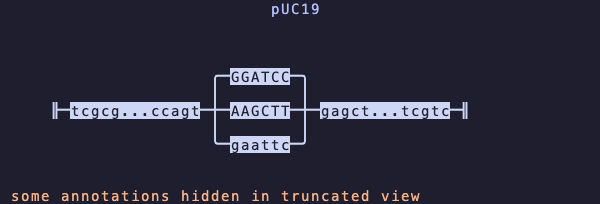

In [11]:
sg_variants

The EcoRI option is still there, so the locus found before stacking is still a valid target.
`eco_ri.start()` is the start of that option: an insertion there goes on the EcoRI route and leaves
the BamHI and HindIII options alone. The exported sequence follows the EcoRI route, so it shows
the change.

In [12]:
sg_variants.insert(eco_ri.start(), "CC")

print("before:", reference_sequence[390:410])
print("after: ", current_sequence(sg_variants)[390:412])

before: CCAGTGAATTCGAGCTCGGT
Exported to file /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-editing-5eo5lh19/variants.fa
after:  CCAGTCCGAATTCGAGCTCGGT


## History

Each edit above is its own operation, newest first. Edits without a `message` get a generated one.

In [13]:
for operation in repo.get_operations()[:10]:
    print(operation.message)

pUC19: insert ba339d81729c897d7ae870ef176f82a0:395-395 in sample 'variants'
pUC19: replace ba339d81729c897d7ae870ef176f82a0:395-401 in sample 'variants'
pUC19: replace ba339d81729c897d7ae870ef176f82a0:395-401 in sample 'variants'
copied sample 'reference' to 'variants'
pUC19: delete ba339d81729c897d7ae870ef176f82a0:562-575 in sample 'edited'
pUC19: replace ba339d81729c897d7ae870ef176f82a0:2483-2486 in sample 'edited'
Add stop codon after FLAG tag
pUC19: insert ba339d81729c897d7ae870ef176f82a0:401-401 in sample 'edited'
copied sample 'reference' to 'edited'
Genbank Import of /Users/bvh/git/gen/gen-python/examples/puc19.gbk
